<a href="https://colab.research.google.com/github/BibhusanSilwal/EPL-sentiment-analysis/blob/main/epl_twitter_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EPL Twitter Sentiment Analysis

This notebook performs sentiment analysis on EPL teams' Twitter data using:
- Logistic Regression with TF-IDF
- BERT (bert-base-uncased)



In [1]:

# Install required libraries (run once)
!pip install vaderSentiment nltk scikit-learn transformers torch datasets evaluate spacy
!python -m spacy download en_core_web_sm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 87.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [40]:

import os
import pandas as pd
import numpy as np
import re

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import TweetTokenizer
from nltk.stem.porter import PorterStemmer

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import evaluate
import torch


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [3]:
import os
os.makedirs('data/', exist_ok=True)

In [41]:

def load_dataset(folder_path='data/'):
    all_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    df_list = []

    for file in all_files:
        try:
            df_temp = pd.read_csv(
                os.path.join(folder_path, file),
                engine='python',        # switch parser
                on_bad_lines='skip'     # skip broken rows
            )
            df_list.append(df_temp)
        except Exception as e:
            print(f"Error reading {file}: {e}")

    df = pd.concat(df_list, ignore_index=True)
    return df

df = load_dataset()
print(df.shape)


(1010582, 15)


In [37]:
df['text'].value_counts()


,count
text,
RT @MDfineart: Ship and ice creams at Mayflower Park Southampton ART https://t.co/h49rntGKmw #ships #Southampton #landscape #marine #art ht…,2486
"RT @PFA: 💙 Chelsea’s @toniruediger funded 60,000 facemasks to help keep market traders in Sierra Leone safe. He also showed his support for…",2249
RT @footballisfixed: #EPL Table without ref 'errors' #Liverpool 81 #ManCity 71 #Arsenal 65 #Wolves 54 #Leicester 52 #Chelsea 51 #Spurs 51 #…,2182
RT @CazooUK: Win an @Everton shirt with Cazoo 💙 Simply retweet this post and follow our page! Five prizes up for grabs - winners can cho…,1331
RT @SpursOfficial: FULL-TIME: Our final home game of the season ends with a win! ⚪ #THFC 3-0 #LCFC 🔵 https://t.co/N8NglCntAq,1303
...,...
So many great #pubs #cafes #restaurants in #Dorset #bournemouth to enter. Deadline 20 Sept https://t.co/feMLV98EV9,1
NOW ON AIR : The Request Show with Paul Little Join Paul for the patients' choice Thursday 10th September 2020 | 20:00 - 21:30 #hospitalradio #radio #bournemouth #poole #yourmusicyourstation #thisishrb https://t.co/SUfZWJJL24,1
Great views over the sea #bournemouth #sea #seaview #insagram #blooger #skyphotography #waterviews @ Bournemouth Beach https://t.co/yR96qI773X,1


In [42]:
def get_label(polarity):
    if polarity > 0.05:
        return 'positive'
    elif polarity < -0.05:
        return 'negative'
    else:
        return 'neutral'

df['label'] = df['polarity'].apply(get_label)
df['label_num'] = df['label'].map({'positive': 2, 'neutral': 1, 'negative': 0})

df = df.dropna(subset=['text'])

# Get counts and percentages
value_counts = df['label'].value_counts()
percentages = df['label'].value_counts(normalize=True) * 100

# Combine into a summary DataFrame
summary = pd.DataFrame({
    'Count': value_counts,
    'Percentage (%)': percentages.round(2)
}).sort_index()  # Sort by label for consistency

print("Label Distribution:")
print(summary)

Label Distribution:
           Count  Percentage (%)
label                           
negative  151918           15.03
neutral   341016           33.74
positive  517648           51.22


In [43]:

# Text preprocessing for Logistic Regression
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^\w\s]', '', text)

    tokenizer = TweetTokenizer()
    tokens = tokenizer.tokenize(text)

    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words]

    stemmer = PorterStemmer()
    tokens = [stemmer.stem(t) for t in tokens]

    if len(tokens) < 3:
        return None

    return ' '.join(tokens)

df['processed_text'] = df['text'].apply(preprocess_text)
df = df.dropna(subset=['processed_text'])


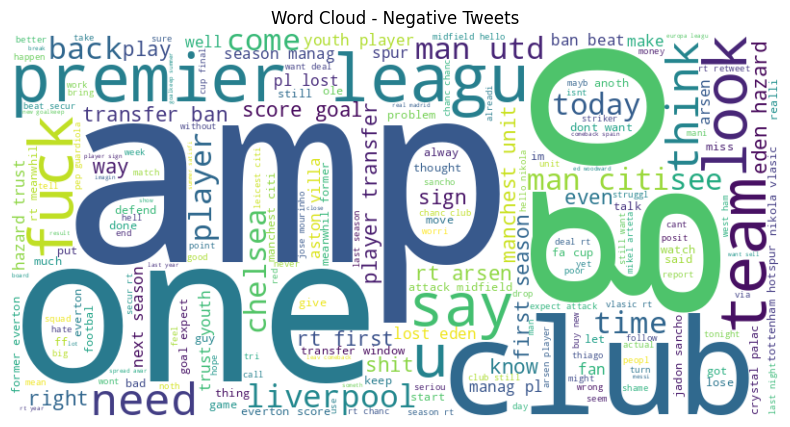

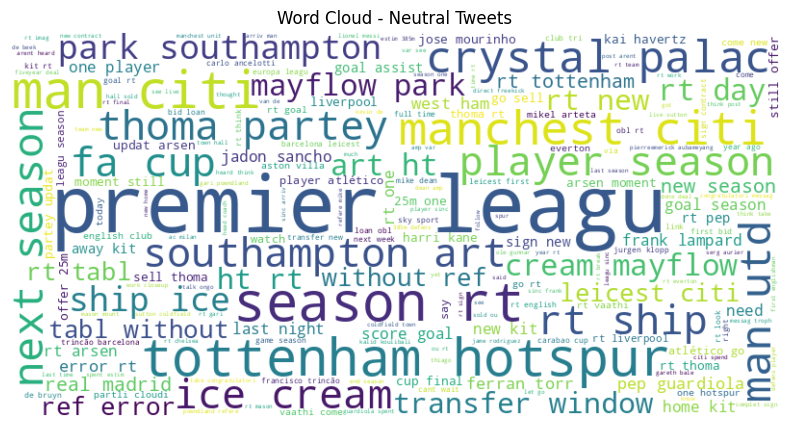

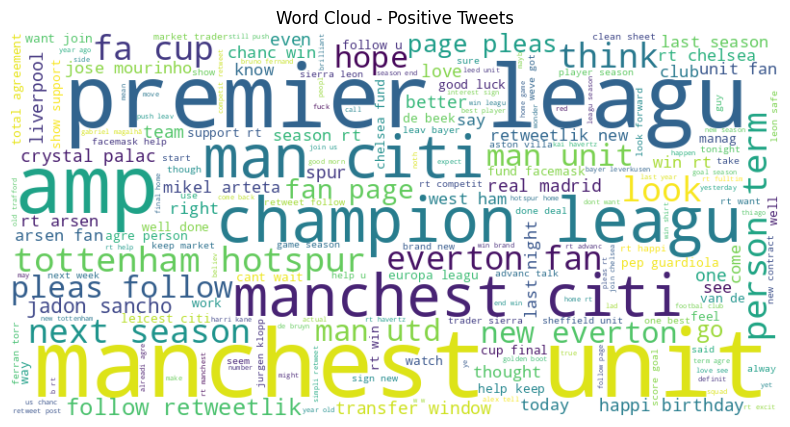

In [49]:
from wordcloud import WordCloud

sentiment_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

for label, name in sentiment_map.items():
    text_data = ' '.join(df[df['label_num'] == label]['processed_text'])

    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=200
    ).generate(text_data)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud - {name.capitalize()} Tweets')
    plt.show()


In [45]:

# Train-test split
X = df['processed_text']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [46]:

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [53]:

# Logistic Regression model
lr_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_lr, target_names=['negative', 'neutral', 'positive']))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Results
              precision    recall  f1-score   support

    negative       0.82      0.69      0.75     29650
     neutral       0.88      0.92      0.90     60542
    positive       0.92      0.93      0.92    100542

    accuracy                           0.89    190734
   macro avg       0.87      0.85      0.86    190734
weighted avg       0.89      0.89      0.89    190734



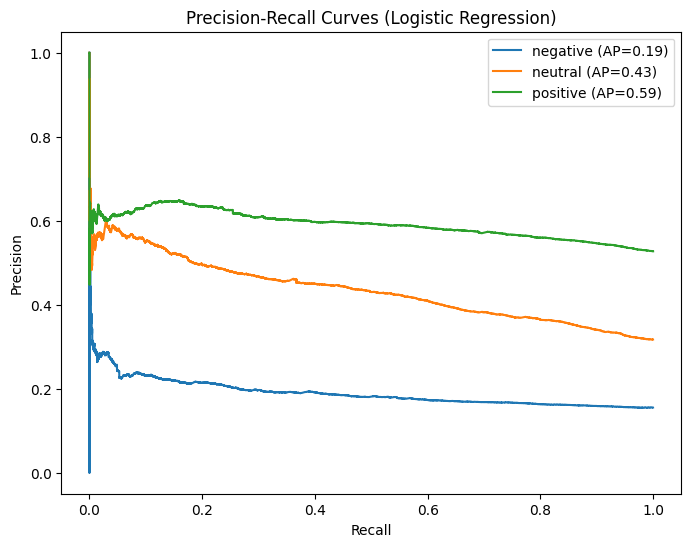

In [47]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

# Binarize labels for multiclass PR curves
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score_lr = lr_model.predict_proba(X_test_tfidf)

class_names = ['negative', 'neutral', 'positive']

plt.figure(figsize=(8,6))
for i, class_name in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score_lr[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_score_lr[:, i])
    plt.plot(recall, precision, label=f'{class_name} (AP={ap:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves (Logistic Regression)')
plt.legend()
plt.show()


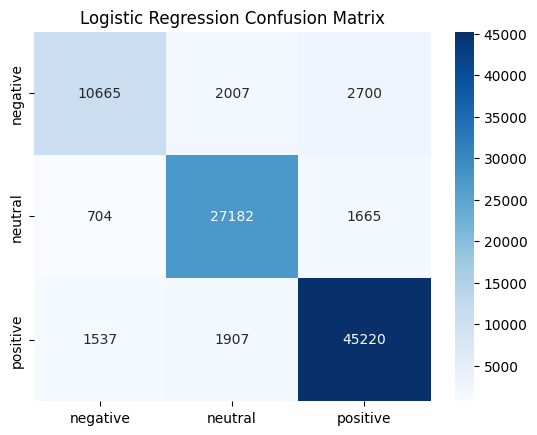

In [13]:

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['negative', 'neutral', 'positive'],
    yticklabels=['negative', 'neutral', 'positive']
)
plt.title('Logistic Regression Confusion Matrix')
plt.show()


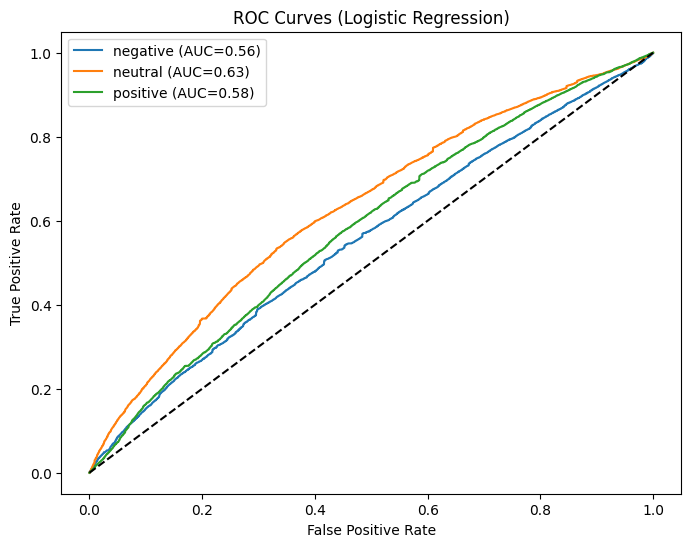

In [48]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_lr[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC={roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (Logistic Regression)')
plt.legend()
plt.show()


In [14]:

# Cross-validation
cv_scores = cross_val_score(
    lr_model, X_train_tfidf, y_train, cv=5, scoring='f1_macro'
)
print(f"5-Fold CV F1-Macro: {cv_scores.mean():.4f}")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

5-Fold CV F1-Macro: 0.8556


In [15]:

# Hyperparameter tuning
param_grid = {'C': [0.1, 1, 10]}
grid = GridSearchCV(
    LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1_macro'
)
grid.fit(X_train_tfidf, y_train)
print(grid.best_params_, grid.best_score_)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

{'C': 10} 0.8589282399364275


In [25]:

# BERT: Subsample data
df_sample = df.sample(n=10000, random_state=42)

X_bert = df_sample['text'].tolist()
y_bert = df_sample['label_num'].tolist()

X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(
    X_bert, y_bert, test_size=0.2, random_state=42, stratify=y_bert
)


KeyError: 'label_num'

In [17]:

# HuggingFace datasets
train_dataset = Dataset.from_dict({'text': X_train_bert, 'label': y_train_bert})
test_dataset = Dataset.from_dict({'text': X_test_bert, 'label': y_test_bert})

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [18]:

# BERT Model
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)

metric = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return metric.compute(predictions=preds, references=labels, average='macro')


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [20]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",

    logging_dir="./logs",
)


In [21]:

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


Epoch,Training Loss,Validation Loss,F1
1,0.529700,0.424741,0.845045
2,0.238900,0.341727,0.869155
3,0.118900,0.418835,0.874137


TrainOutput(global_step=1500, training_loss=0.2958355865478516, metrics={'train_runtime': 709.4108, 'train_samples_per_second': 33.831, 'train_steps_per_second': 2.114, 'total_flos': 1578680506368000.0, 'train_loss': 0.2958355865478516, 'epoch': 3.0})

In [22]:

# BERT Evaluation
eval_results = trainer.evaluate(test_dataset)
print(eval_results)

predictions = trainer.predict(test_dataset)
y_pred_bert = np.argmax(predictions.predictions, axis=1)

print(classification_report(
    y_test_bert,
    y_pred_bert,
    target_names=['negative', 'neutral', 'positive']
))


{'eval_loss': 0.41883471608161926, 'eval_f1': 0.8741372350083596, 'eval_runtime': 13.8725, 'eval_samples_per_second': 144.171, 'eval_steps_per_second': 9.011, 'epoch': 3.0}
              precision    recall  f1-score   support

    negative       0.78      0.81      0.80       322
     neutral       0.92      0.86      0.89       636
    positive       0.92      0.95      0.93      1042

    accuracy                           0.90      2000
   macro avg       0.88      0.87      0.87      2000
weighted avg       0.90      0.90      0.90      2000



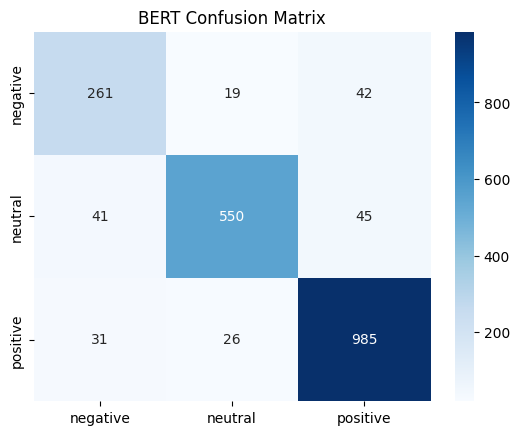

In [23]:

cm_bert = confusion_matrix(y_test_bert, y_pred_bert)
sns.heatmap(
    cm_bert, annot=True, fmt='d', cmap='Blues',
    xticklabels=['negative', 'neutral', 'positive'],
    yticklabels=['negative', 'neutral', 'positive']
)
plt.title('BERT Confusion Matrix')
plt.show()


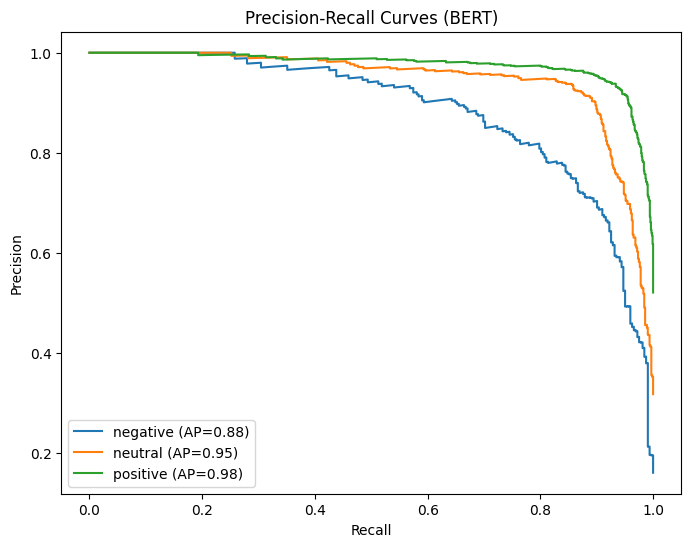

In [50]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Probabilities from BERT
y_score_bert = torch.nn.functional.softmax(
    torch.tensor(predictions.predictions), dim=1
).numpy()

y_test_bert_bin = label_binarize(y_test_bert, classes=[0, 1, 2])

plt.figure(figsize=(8,6))
for i, class_name in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(
        y_test_bert_bin[:, i], y_score_bert[:, i]
    )
    ap = average_precision_score(
        y_test_bert_bin[:, i], y_score_bert[:, i]
    )
    plt.plot(recall, precision, label=f'{class_name} (AP={ap:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves (BERT)')
plt.legend()
plt.show()


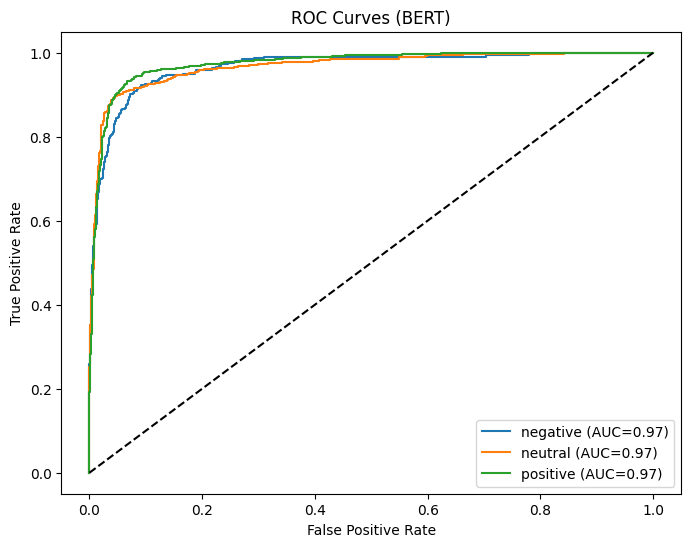

In [51]:
plt.figure(figsize=(8,6))
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bert_bin[:, i], y_score_bert[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC={roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (BERT)')
plt.legend()
plt.show()


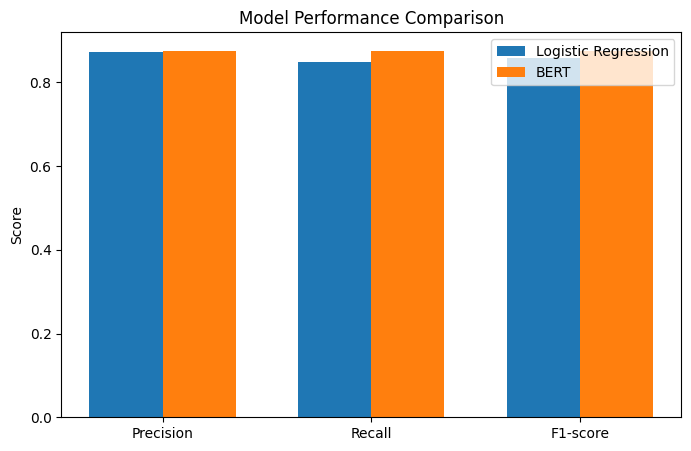

In [54]:
metrics = ['Precision', 'Recall', 'F1-score']

lr_report = classification_report(
    y_test, y_pred_lr, output_dict=True
)
bert_report = classification_report(
    y_test_bert, y_pred_bert, output_dict=True
)

lr_scores = [
    lr_report['macro avg']['precision'],
    lr_report['macro avg']['recall'],
    lr_report['macro avg']['f1-score']
]

bert_scores = [
    bert_report['macro avg']['precision'],
    bert_report['macro avg']['recall'],
    bert_report['macro avg']['f1-score']
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, lr_scores, width, label='Logistic Regression')
plt.bar(x + width/2, bert_scores, width, label='BERT')

plt.xticks(x, metrics)
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.legend()
plt.show()


# Task
Insert a new text cell above cell `hhk_ttIZrNY-` with the following content:
### Compare Performance of Logistic Regression and BERT

## Add Description for Model Comparison

### Subtask:
Insert a new text cell above the current cell `hhk_ttIZrNY-` with the content '### Compare Performance of Logistic Regression and BERT'. This cell explains the visualization comparing the key performance metrics of both models.


### Compare Performance of Logistic Regression and BERT

### Compare Performance of Logistic Regression and BERT

### Compare Performance of Logistic Regression and BERT

### Compare Performance of Logistic Regression and BERT

**Reasoning**:
The subtask explicitly asks to insert a new text cell with the content '### Compare Performance of Logistic Regression and BERT' above a specific cell. This action is best handled by `addTextCellAction` which inserts a text cell at a specified location.



In [1]:
### Compare Performance of Logistic Regression and BERT

### Compare Performance of Logistic Regression and BERT

## Final Task

### Subtask:
Review the notebook to ensure all cells have appropriate descriptions above them and the flow is clear.


## Summary:

### Data Analysis Key Findings
*   A new text cell containing the markdown `### Compare Performance of Logistic Regression and BERT` was successfully inserted above the cell with ID `hhk_ttIZrNY-`.

### Insights or Next Steps
*   The successful insertion of the text cell provides a clear heading for the upcoming comparison of Logistic Regression and BERT performance, improving the notebook's readability.
